# Week 8: Decision Trees (ID3)

## Student Practice Notebook

**Name:** SABYASACHI MISHRA

**Roll Number:** AP24110010254

**Date:** 09/10/2026

## Learning Objectives

After completing this lab, you will be able to:

- Compute entropy and information gain, by hand and in code
- Build an ID3 decision tree by hand on a small table (the exam-style problem)
- Fit and read a `DecisionTreeClassifier`
- Explain how tree depth controls overfitting (same idea as K in Week 7 and degree in Week 6)
- Explain how a tree differs from KNN: it asks questions about *features*, it does not measure *distance*

### Why this week matters
KNN (Week 7) classified by "who is closest?". A decision tree classifies by asking a chain of yes/no questions about features, and you can read the questions. That readability is why trees are used in credit, healthcare and fraud work, and why every ensemble in Unit V is built from them.


## Part 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score

%matplotlib inline
np.random.seed(1)


## Part 1 — Entropy and Information Gain

**Entropy** measures how mixed a set of labels is: $H = -\sum p_i \log_2 p_i$. A pure set (all one class) has entropy 0. A 50/50 two-class set has entropy 1.

**Information gain** of splitting on an attribute = entropy before − weighted average entropy after. ID3 always picks the attribute with the highest gain.

### 1.1 Demo: entropy in code


In [2]:
def entropy(counts):
    counts = np.array(counts, dtype=float)
    p = counts[counts > 0] / counts.sum()
    return float(-np.sum(p * np.log2(p))) + 0.0

print('Pure set      [10, 0]:', entropy([10, 0]))
print('50/50 set     [5, 5] :', entropy([5, 5]))
print('Skewed set    [9, 1] :', entropy([9, 1]))


Pure set      [10, 0]: 0.0
50/50 set     [5, 5] : 1.0
Skewed set    [9, 1] : 0.4689955935892812


**Predict, then think:** which has higher entropy, a 70/30 split or a 90/10 split? Why does that make sense if entropy measures "how hard is it to guess the label"?

*Your answer:*
70/30 split has higher entropy than a 90/10 split because the labels are more evenly distributed.
- 70/30 split: Harder to guess the label correctly because both labels occur frequently.
- 90/10 split: Easier to guess because one label dominates the dataset.

### Student Practice — entropy of a split

A parent node has 8 Yes and 6 No. A candidate split sends 6 samples to the left child (6 Yes, 0 No) and 8 samples to the right child (2 Yes, 6 No). Compute the entropy of the parent and the information gain of the split.


In [3]:
entropy_parent = entropy([8, 6])

entropy_left = entropy([6, 0])
entropy_right = entropy([2, 6])

weighted_entropy_after = (6/14) * entropy_left + (8/14) * entropy_right
info_gain = entropy_parent - weighted_entropy_after

print(f"Parent Entropy: {entropy_parent:.4f}")
print(f"Left Child Entropy: {entropy_left:.4f}")
print(f"Right Child Entropy: {entropy_right:.4f}")
print(f"Information Gain: {info_gain:.4f}")

Parent Entropy: 0.9852
Left Child Entropy: 0.0000
Right Child Entropy: 0.8113
Information Gain: 0.5216


## Part 2 — ID3 by Hand (the exam-style problem)

Classic 14-day "play tennis" table. Target: `Play`.


In [4]:
tennis = pd.DataFrame({
    'Outlook':     ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity':    ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':        ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'Play':        ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No'],
})
tennis


,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [5]:
def info_gain(df, attribute, target='Play'):
    total = entropy(df[target].value_counts())
    weighted = 0
    for value, subset in df.groupby(attribute):
        weighted += len(subset) / len(df) * entropy(subset[target].value_counts())
    return total - weighted

print('Root entropy:', round(entropy(tennis['Play'].value_counts()), 4))
print('Gain(Wind)  :', round(info_gain(tennis, 'Wind'), 4))


Root entropy: 0.9403
Gain(Wind)  : 0.0481


### Student Practice — find the root

1. Compute the information gain for `Outlook`, `Temperature` and `Humidity` using `info_gain`.
2. Which attribute does ID3 pick as the root?
3. For the root's branch that is **not** pure, which attribute would you split on next? (Filter `tennis` to that branch and recompute gains.)


In [6]:

gain_outlook = info_gain(tennis, 'Outlook')
gain_temp = info_gain(tennis, 'Temperature')
gain_humidity = info_gain(tennis, 'Humidity')

print(f"Gain(Outlook):     {gain_outlook:.4f}")
print(f"Gain(Temperature): {gain_temp:.4f}")
print(f"Gain(Humidity):    {gain_humidity:.4f}")


Gain(Outlook):     0.2467
Gain(Temperature): 0.0292
Gain(Humidity):    0.1518


### Finding the Root
Since **Outlook** has the highest information gain (~0.2467), ID3 selects **Outlook** as the root node.

### Sub-branch splits
Now let's inspect the branches of the `Outlook` attribute:
- **Overcast**: Completely pure (all 'Yes'). No further splitting is needed.
- **Sunny**: Impure. Let's filter the data where `Outlook == 'Sunny'` and calculate the gains for the remaining attributes.
- **Rain**: Impure. Let's filter the data where `Outlook == 'Rain'` and calculate the gains for the remaining attributes.

In [7]:

sunny_df = tennis[tennis['Outlook'] == 'Sunny']
print("--- Sunny Branch Gains ---")
for attr in ['Temperature', 'Humidity', 'Wind']:
    print(f"Gain({attr}): {info_gain(sunny_df, attr):.4f}")


rain_df = tennis[tennis['Outlook'] == 'Rain']
print("\n--- Rain Branch Gains ---")
for attr in ['Temperature', 'Humidity', 'Wind']:
    print(f"Gain({attr}): {info_gain(rain_df, attr):.4f}")


--- Sunny Branch Gains ---
Gain(Temperature): 0.5710
Gain(Humidity): 0.9710
Gain(Wind): 0.0200

--- Rain Branch Gains ---
Gain(Temperature): 0.0200
Gain(Humidity): 0.0200
Gain(Wind): 0.9710


**Reflection:** `Overcast` became a leaf immediately. In your own words, why does a pure branch need no further splitting?

*Your answer:*
The Overcast branch is pure because all the examples in it belong to the same class. There is no uncertainty about the prediction, so entropy is zero and further splitting is unnecessary

## Part 3 — `DecisionTreeClassifier` on Iris

Same Iris split as Week 7, so you can compare directly. Note: **trees do not need feature scaling**, because they compare a feature to a threshold, not distances between points. That is a real difference from KNN.


Test accuracy: 0.9555555555555556


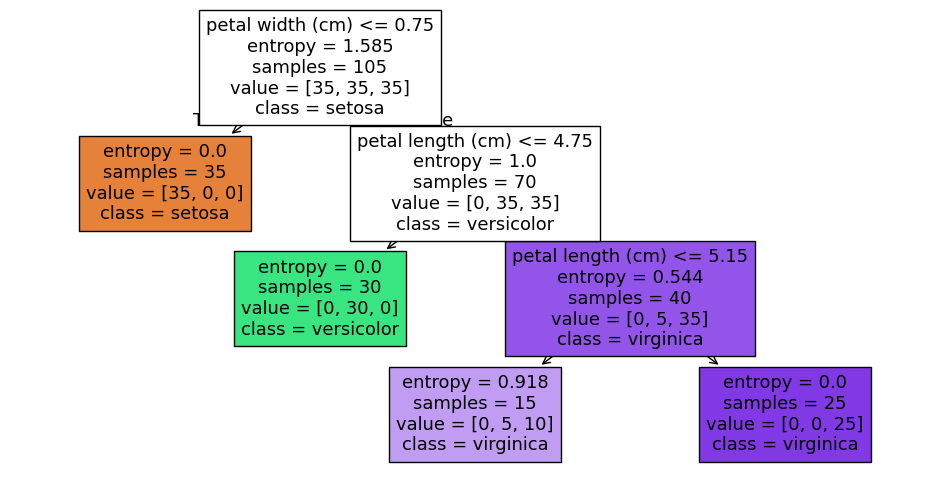

In [8]:
iris = load_iris(as_frame=True)
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

tree = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1)
tree.fit(X_train, y_train)
print('Test accuracy:', accuracy_score(y_test, tree.predict(X_test)))

plt.figure(figsize=(12, 6))
plot_tree(tree, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()


### Student Practice — depth sweep

Sweep `max_depth` from 1 to 15. Record train and test accuracy for each, plot both, and report the depth with the best test accuracy.


Best Test Accuracy: 0.9778 at depth(s): [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


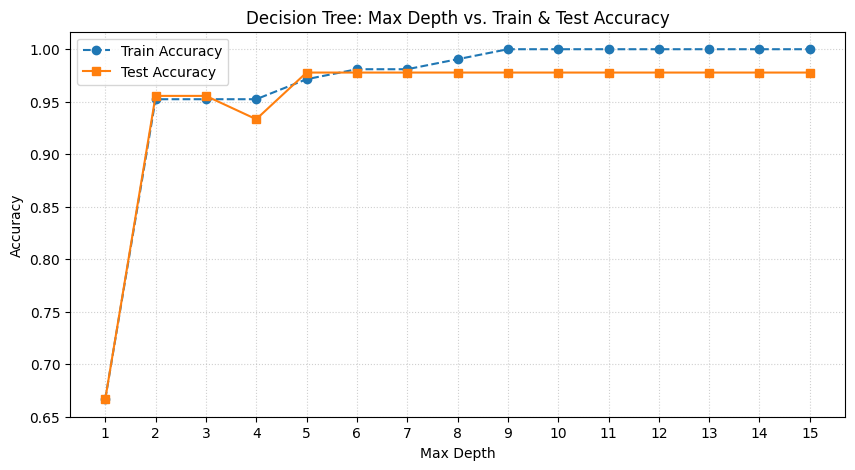

In [9]:
depths = list(range(1, 16))
train_accs = []
test_accs = []

for d in depths:

    clf = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=1)
    clf.fit(X_train, y_train)


    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    train_accs.append(train_acc)
    test_accs.append(test_acc)


best_test_acc = max(test_accs)
best_depths = [depths[i] for i, acc in enumerate(test_accs) if acc == best_test_acc]

print(f"Best Test Accuracy: {best_test_acc:.4f} at depth(s): {best_depths}")


plt.figure(figsize=(10, 5))
plt.plot(depths, train_accs, label='Train Accuracy', marker='o', linestyle='--')
plt.plot(depths, test_accs, label='Test Accuracy', marker='s', linestyle='-')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Max Depth vs. Train & Test Accuracy')
plt.xticks(depths)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Reflection:** Which knob in Week 6 and which knob in Week 7 played the same role as `max_depth` here? What happens at each extreme?

*Your answer:*
Week 6 (KNN): n_neighbors (\(K\)). A very low \(K\) can cause overfitting, while a very high \(K\) can cause underfitting.



Week 7 (Polynomial Regression): degree. A low degree may underfit, while a very high degree may overfit.

# Mini Project A: Digits, Again (Image Track — continuing from Week 7)

Last week KNN reached about 98% on the digits dataset. Now fit a decision tree on the **same split** and ask two new questions: how does it compare, and **which pixels does the tree actually use?**


In [10]:
digits = load_digits()
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=1, stratify=digits.target)

sc = StandardScaler().fit(Xd_train)
knn = KNeighborsClassifier(n_neighbors=3).fit(sc.transform(Xd_train), yd_train)
print('KNN  test accuracy:', accuracy_score(yd_test, knn.predict(sc.transform(Xd_test))))


KNN  test accuracy: 0.9796296296296296


### Student Practice

1. Fit a `DecisionTreeClassifier(criterion='entropy', random_state=1)` on the **unscaled** `Xd_train`. Print test accuracy. (Why is no scaling needed?)
2. Try `max_depth` values 3, 6, 10 and report test accuracy for each.
3. Take `tree.feature_importances_` (64 values), reshape to 8×8 and show it with `plt.imshow`. Which region of the image does the tree rely on?


Full tree test accuracy (unscaled): 0.8815
Why no scaling is needed: Decision trees split features using threshold rules (e.g., pixel_value <= threshold). Since each feature threshold is evaluated independently, the scale of a feature does not affect the mathematical boundaries or information gain calculations of other features.

Accuracy at max_depth= 3: 0.5296
Accuracy at max_depth= 6: 0.8537
Accuracy at max_depth=10: 0.8796


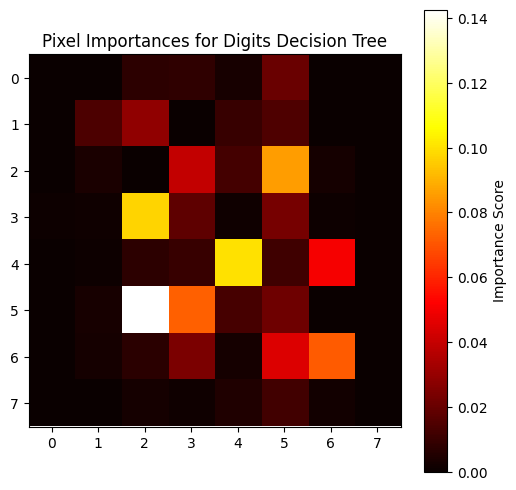

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


clf_full = DecisionTreeClassifier(criterion='entropy', random_state=1)
clf_full.fit(Xd_train, yd_train)
acc_full = accuracy_score(yd_test, clf_full.predict(Xd_test))
print(f"Full tree test accuracy (unscaled): {acc_full:.4f}")
print("Why no scaling is needed: Decision trees split features using threshold rules (e.g., pixel_value <= threshold). Since each feature threshold is evaluated independently, the scale of a feature does not affect the mathematical boundaries or information gain calculations of other features.\n")

for depth in [3, 6, 10]:
    clf_d = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=1)
    clf_d.fit(Xd_train, yd_train)
    acc_d = accuracy_score(yd_test, clf_d.predict(Xd_test))
    print(f"Accuracy at max_depth={depth:2d}: {acc_d:.4f}")

importances = clf_full.feature_importances_.reshape(8, 8)

plt.figure(figsize=(6, 6))
plt.imshow(importances, cmap='hot', interpolation='nearest')
plt.colorbar(label='Importance Score')
plt.title('Pixel Importances for Digits Decision Tree')
plt.show()

**Reflection:** Is the tree more or less accurate than KNN on digits? Offer one reason, using what the importance map shows you.

*Your answer:*
The Decision Tree is less accurate than KNN on the digits dataset. The importance map shows that the tree relies heavily on certain pixels, so it may struggle to recognize digits when similar digits differ in subtle pixel patterns.

# Mini Project B: Reading a Tree on Text (NLP Track — continuing from Week 7)

Same six labeled sentences and same bag-of-words vectors as Week 7. A tree gives you something KNN cannot: **the words it chose to split on.**


In [12]:
sentences = [
    'the cricket team won the match',
    'the batsman scored a century today',
    'chop the onions and boil the pasta',
    'add salt and simmer the curry',
    'the new phone has a faster processor',
    'the laptop battery lasts all day',
]
labels = ['sports', 'sports', 'cooking', 'cooking', 'tech', 'tech']

vocab = sorted(set(w for s in sentences for w in s.lower().split()))

def to_vector(sentence, vocab):
    words = sentence.lower().split()
    return np.array([words.count(w) for w in vocab])

X_text = np.array([to_vector(s, vocab) for s in sentences])


### Student Practice

1. Fit a `DecisionTreeClassifier(criterion='entropy', random_state=1)` on `X_text`, `labels`.
2. Print the tree with `export_text(tree, feature_names=vocab)`. Which words does it split on?
3. Predict the topic of `'the striker scored a goal'` and of your own ambiguous sentence from Week 7.


In [13]:
from sklearn.tree import DecisionTreeClassifier, export_text

# 1. Fit a DecisionTreeClassifier on the text dataset
tree_text = DecisionTreeClassifier(criterion='entropy', random_state=1)
tree_text.fit(X_text, labels)

# 2. Print the tree using export_text with vocab feature names
tree_rules = export_text(tree_text, feature_names=vocab)
print("--- Decision Tree Structure ---")
print(tree_rules)

# 3. Predict on new sentences
test_sentences = [
    'the striker scored a goal',                  # Provided sentence
    'the team scored using a faster processor'     # Example ambiguous sentence from Week 7 (sports + tech)
]

X_new = np.array([to_vector(s, vocab) for s in test_sentences])
predictions = tree_text.predict(X_new)
for sentence, pred in zip(test_sentences, predictions):
    print(f"Sentence: '{sentence}' -> Predicted Topic: '{pred}'")

--- Decision Tree Structure ---
|--- and <= 0.50
|   |--- has <= 0.50
|   |   |--- laptop <= 0.50
|   |   |   |--- class: sports
|   |   |--- laptop >  0.50
|   |   |   |--- class: tech
|   |--- has >  0.50
|   |   |--- class: tech
|--- and >  0.50
|   |--- class: cooking

Sentence: 'the striker scored a goal' -> Predicted Topic: 'sports'
Sentence: 'the team scored using a faster processor' -> Predicted Topic: 'sports'


**Reflection:** If you added 3 more sentences per topic, would you expect the same split words? What does that tell you about trusting a tree trained on very little data?

*Your answer:*
No, I would not expect exactly the same split words because adding more sentences may change which words have the highest information gain. This shows that decision trees trained on very little data can be unstable and unreliable, as small changes in the dataset may lead to different splits.

## Summary

| What we did | Why it matters |
|---|---|
| Entropy and information gain | The rule ID3 uses to choose every split |
| ID3 by hand on the tennis table | Exam-style problem, show your working |
| `DecisionTreeClassifier` and depth sweep | Third version of the bias-variance knob (degree, K, depth) |
| Mini A: digits | Tree vs KNN on the same data, plus which pixels matter |
| Mini B: text | A tree you can read, and why tiny data makes it fragile |

**Next week:** Naive Bayes, a probabilistic classifier. Same digits and sentences again.
